# Discovering Hidden Topics in News Headlines

*An interactive walk through **Latent Dirichlet Allocation (LDA)** — one of the
classic algorithms of natural language processing.*

Imagine you're handed a million news headlines with **no labels, no categories,
nothing**. Could a machine read them all and figure out, on its own, that some
are about *crime*, others about *the economy*, others about *politics*?

That's exactly what LDA does. It's an **unsupervised** model: you give it raw
text, tell it *how many* topics to look for, and it discovers the rest — which
words tend to appear together, and which topics each document is a blend of.

In this notebook we'll run the whole thing end to end on real ABC News
headlines, and then *watch* the topics emerge as word clouds. No prior NLP
experience needed — we'll explain each step as we go.

## How LDA thinks about text

LDA makes one simple, surprisingly powerful assumption:

> Every document is a **mixture of topics**, and every topic is a
> **mixture of words**.

A headline like *"police investigate fatal highway crash"* might be 80% a
"crime & accidents" topic and 20% a "transport" topic. LDA never sees those
labels — it just notices that *police*, *crash*, and *investigate* keep showing
up together, and groups them into a topic. We get to read the topic afterwards
and give it a human name.

Let's get started.

## Setup

We'll lean on three workhorse libraries: **gensim** (the LDA engine), **NLTK** (text cleaning), and **pandas** (data wrangling).

In [1]:
import gensim
import nltk
import pandas as pd
from gensim import corpora, models
from gensim.utils import simple_preprocess
from nltk.stem import WordNetLemmatizer

# WordNet powers our lemmatizer (turning "running" -> "run", etc.)
for pkg in ("wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)

pd.set_option("display.max_colwidth", 80)

## 1. Load the headlines

We use a **sample** of 25,000 headlines that ships with the repo, so this runs
in seconds. Want the full ~1.2 million? See [`data/README.md`](../data/README.md).

In [2]:
df = pd.read_csv("../data/sample_headlines.csv", on_bad_lines="skip")
print(f"{len(df):,} headlines loaded")
df.head()

25,000 headlines loaded


,publish_date,headline_text
0,20100214,billion dollar hole in liberals hospital plan
1,20100429,planned bauxite mine brings river worries
2,20130116,hong kong social worker sze lai shan speaks to
3,20131105,teenage girl shot in back in western sydney
4,20101214,united overpowers arsenal to the top


## 2. Clean the text

Raw text is noisy. Before a model can find structure, we tidy each headline:

1. **Tokenize** — split into lowercase words, drop punctuation.
2. **Remove stopwords** — toss filler like *the*, *and*, *says* that carry no topic.
3. **Drop very short words** — anything under 4 letters is usually noise.
4. **Lemmatize** — collapse word forms to a base (*killed*, *killing* → *kill*)
   so the model treats them as one signal.

Here's the function that does all four:

In [3]:
STOPWORDS = gensim.parsing.preprocessing.STOPWORDS.union(
    {"says", "say", "new", "year", "australia", "australian", "abc"}
)
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = []
    for token in simple_preprocess(text, deacc=True):
        if token in STOPWORDS or len(token) < 4:
            continue
        tokens.append(lemmatizer.lemmatize(token, pos="v"))
    return tokens

# See it in action on a single headline:
example = df["headline_text"].iloc[10]
print("before:", example)
print("after :", preprocess(example))

before: force no match for hurricanes


after : ['force', 'match', 'hurricanes']


In [4]:
# Apply the cleaning to every headline
docs = df["headline_text"].dropna().map(preprocess)
docs.head()

0    [billion, dollar, hole, liberals, hospital, plan]
1                 [plan, bauxite, bring, river, worry]
2            [hong, kong, social, worker, shan, speak]
3              [teenage, girl, shoot, western, sydney]
4                          [unite, overpower, arsenal]
Name: headline_text, dtype: object

## 3. Build a dictionary and corpus

LDA doesn't read words — it reads numbers. So we:

- build a **dictionary** mapping every word to an integer id, and
- represent each headline as a **bag of words**: a list of
  `(word_id, count)` pairs.

We also **filter extremes**: words appearing in fewer than 15 headlines are too
rare to matter, and words in more than half of *all* headlines are too common to
distinguish topics. Both get dropped.

In [5]:
dictionary = corpora.Dictionary(docs)
dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=100_000)
print(f"Vocabulary after filtering: {len(dictionary):,} words")

bow_corpus = [dictionary.doc2bow(doc) for doc in docs]

# What does one headline look like as a bag of words?
sample_bow = bow_corpus[10]
print(example)
print([(dictionary[i], count) for i, count in sample_bow])

Vocabulary after filtering: 1,586 words
force no match for hurricanes
[('force', 1), ('match', 1)]


### A second representation: TF-IDF

Bag-of-words treats every word equally. **TF-IDF** is smarter: it down-weights
words that appear everywhere and boosts words that are distinctive to a few
headlines. We'll train LDA on *both* and compare the topics they find.

In [6]:
tfidf = models.TfidfModel(bow_corpus)
tfidf_corpus = tfidf[bow_corpus]

## 4. Train LDA on the bag-of-words corpus

Now the main event. We ask for **9 topics** and let gensim's multicore LDA do
several `passes` over the data to refine them. Each topic comes back as a
weighted list of its most characteristic words.

In [7]:
bow_model = models.LdaMulticore(
    bow_corpus, num_topics=9, id2word=dictionary,
    passes=4, workers=2, random_state=42,
)

for idx, topic in bow_model.print_topics(-1):
    print(f"Topic {idx}: {topic}\n")

Topic 0: 0.025*"open" + 0.020*"council" + 0.016*"market" + 0.016*"jail" + 0.016*"defend" + 0.014*"child" + 0.012*"perth" + 0.012*"business" + 0.011*"plan" + 0.011*"blaze"

Topic 1: 0.028*"plan" + 0.025*"miss" + 0.021*"continue" + 0.017*"water" + 0.015*"push" + 0.014*"win" + 0.013*"green" + 0.012*"price" + 0.011*"search" + 0.010*"rise"

Topic 2: 0.043*"interview" + 0.018*"report" + 0.017*"minister" + 0.015*"close" + 0.015*"fund" + 0.013*"beat" + 0.013*"community" + 0.012*"final" + 0.012*"group" + 0.011*"award"

Topic 3: 0.042*"charge" + 0.037*"court" + 0.026*"home" + 0.024*"murder" + 0.022*"face" + 0.018*"accuse" + 0.016*"south" + 0.016*"north" + 0.015*"world" + 0.015*"drug"

Topic 4: 0.018*"china" + 0.017*"share" + 0.015*"rise" + 0.014*"live" + 0.014*"trump" + 0.014*"bank" + 0.013*"free" + 0.012*"company" + 0.011*"brisbane" + 0.010*"find"

Topic 5: 0.032*"govt" + 0.021*"help" + 0.017*"school" + 0.015*"family" + 0.012*"die" + 0.011*"fear" + 0.011*"call" + 0.010*"want" + 0.010*"land" + 0

**Read the topics like a human would.** Even though the model had zero labels,
clear themes jump out — for example:

- a **crime & policing** topic (*police, charge, murder, accuse, shoot*),
- an **accidents & courts** topic (*crash, court, death, jail, search*),
- a **government & funding** topic (*plan, council, govt, fund, hospital*),
- an **economy & markets** topic (*price, rise, market, share, china*).

That's the magic of LDA: structure discovered entirely from word co-occurrence.

## 5. Train LDA on the TF-IDF corpus

Same model, different input. TF-IDF tends to surface narrower, more specific
topics because distinctive words get more say.

In [8]:
tfidf_model = models.LdaMulticore(
    tfidf_corpus, num_topics=9, id2word=dictionary,
    passes=4, workers=2, random_state=42,
)

for idx, topic in tfidf_model.print_topics(-1):
    print(f"Topic {idx}: {topic}\n")

Topic 0: 0.017*"open" + 0.014*"market" + 0.013*"council" + 0.012*"speak" + 0.011*"business" + 0.011*"plan" + 0.011*"defend" + 0.010*"ahead" + 0.009*"return" + 0.009*"sign"

Topic 1: 0.017*"continue" + 0.014*"win" + 0.014*"miss" + 0.011*"rise" + 0.010*"government" + 0.009*"decision" + 0.009*"investigation" + 0.009*"green" + 0.009*"police" + 0.009*"hunt"

Topic 2: 0.059*"interview" + 0.015*"beat" + 0.013*"close" + 0.011*"award" + 0.011*"future" + 0.010*"extend" + 0.009*"community" + 0.009*"report" + 0.009*"fund" + 0.008*"violence"

Topic 3: 0.028*"charge" + 0.019*"court" + 0.015*"murder" + 0.012*"home" + 0.012*"appeal" + 0.012*"woman" + 0.012*"hear" + 0.011*"accuse" + 0.011*"police" + 0.010*"south"

Topic 4: 0.014*"trump" + 0.013*"share" + 0.013*"deaths" + 0.012*"china" + 0.011*"job" + 0.011*"water" + 0.010*"donald" + 0.010*"england" + 0.010*"tigers" + 0.009*"target"

Topic 5: 0.015*"rural" + 0.014*"die" + 0.013*"school" + 0.010*"land" + 0.009*"govt" + 0.008*"join" + 0.008*"rat" + 0.008*

## 6. Visualize the topics

Lists of weighted words are fine, but topics really come alive as **word
clouds**, where a word's size reflects its importance to the topic.

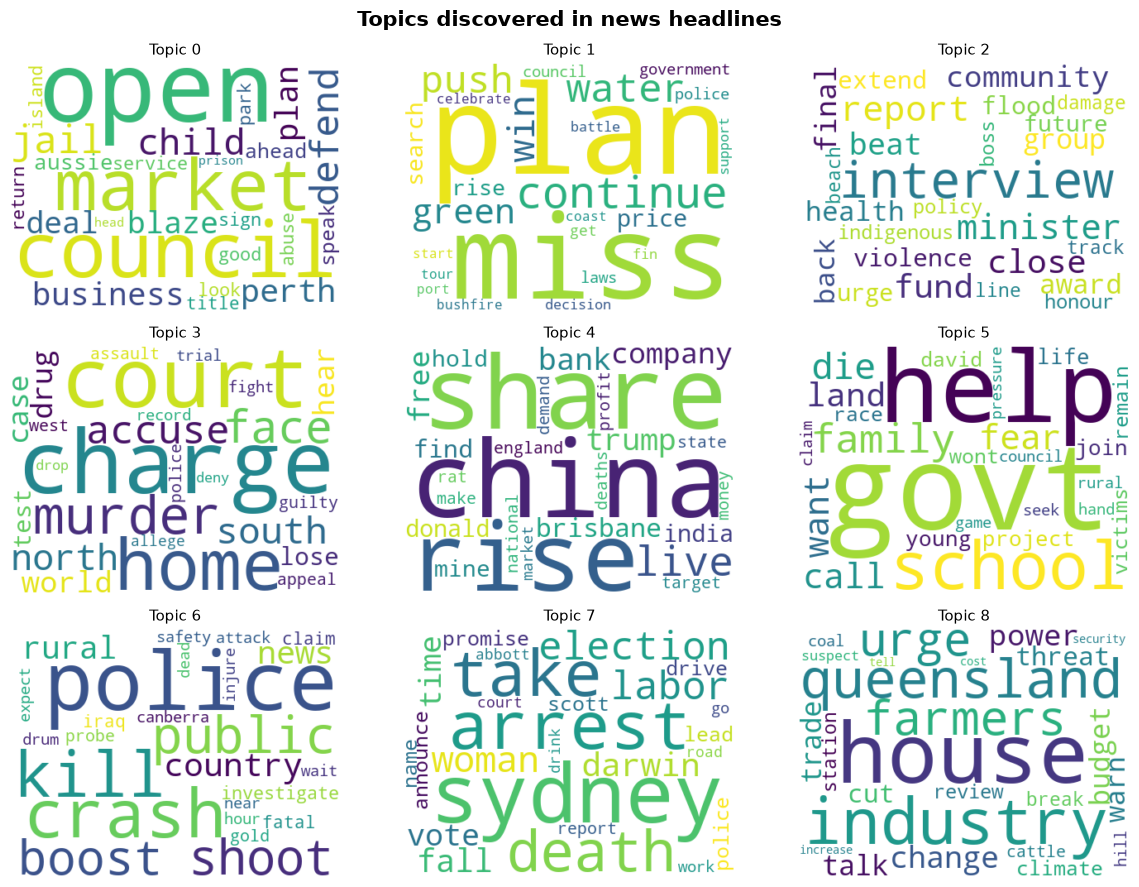

In [9]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

cols = 3
rows = (bow_model.num_topics + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
for ax in axes.flatten():
    ax.axis("off")

for topic_id in range(bow_model.num_topics):
    weights = dict(bow_model.show_topic(topic_id, topn=25))
    cloud = WordCloud(background_color="white", colormap="viridis",
                      width=400, height=300, prefer_horizontal=0.9
                      ).generate_from_frequencies(weights)
    ax = axes.flatten()[topic_id]
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(f"Topic {topic_id}", fontsize=11)

fig.suptitle("Topics discovered in news headlines", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Classify a brand-new headline

The real payoff: once trained, LDA can take a headline it has **never seen** and
tell you which topics it belongs to. Let's try one.

In [10]:
unseen = "Government announces new funding for regional hospitals"
bow_vector = dictionary.doc2bow(preprocess(unseen))

print(f'Headline: "{unseen}"\n')
for topic_id, score in sorted(bow_model[bow_vector], key=lambda x: -x[1]):
    words = bow_model.print_topic(topic_id, topn=5)
    print(f"  {score:5.1%}  ->  Topic {topic_id}: {words}")

Headline: "Government announces new funding for regional hospitals"

  66.9%  ->  Topic 7: 0.031*"sydney" + 0.020*"arrest" + 0.018*"take" + 0.017*"death" + 0.017*"election"
  20.1%  ->  Topic 4: 0.018*"china" + 0.017*"share" + 0.015*"rise" + 0.014*"live" + 0.014*"trump"
   1.9%  ->  Topic 2: 0.043*"interview" + 0.018*"report" + 0.017*"minister" + 0.015*"close" + 0.015*"fund"
   1.9%  ->  Topic 0: 0.025*"open" + 0.020*"council" + 0.016*"market" + 0.016*"jail" + 0.016*"defend"
   1.9%  ->  Topic 6: 0.047*"police" + 0.030*"crash" + 0.027*"kill" + 0.017*"public" + 0.016*"shoot"
   1.9%  ->  Topic 1: 0.028*"plan" + 0.025*"miss" + 0.021*"continue" + 0.017*"water" + 0.015*"push"
   1.9%  ->  Topic 5: 0.032*"govt" + 0.021*"help" + 0.017*"school" + 0.015*"family" + 0.012*"die"
   1.9%  ->  Topic 8: 0.032*"house" + 0.017*"industry" + 0.016*"queensland" + 0.015*"farmers" + 0.015*"urge"
   1.9%  ->  Topic 3: 0.042*"charge" + 0.037*"court" + 0.026*"home" + 0.024*"murder" + 0.022*"face"


## Wrapping up

We took a million-headline firehose and, without a single label, taught a model
to organize it into human-readable themes — then used it to classify new text.

**Where to go next:**

- Sweep `num_topics` and use a **coherence score** to pick the best count.
- Try [pyLDAvis](https://github.com/bmabey/pyLDAvis) for an interactive topic map.
- Swap in your *own* corpus (tweets, reviews, support tickets) — the pipeline is
  the same.

The full, parameterized pipeline lives in
[`src/topic_model.py`](../src/topic_model.py). Thanks for reading!